In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import os
from matplotlib.ticker import FormatStrFormatter, FuncFormatter


In [2]:
TCR1_examples = pd.read_csv('../data/tcr1_pae_examples.csv')

In [17]:
custom_labels = {'V3': 'V3 (WT)', 'V3L': 'V3L (cognate)', 'V3E': 'V3E (non-cognate)'}
custom_colors = ['black', '#3e7da7', '#acacac']   

In [13]:
TCR1_examples_rmsd = pd.read_csv('../data/tcr1_rmsd_examples.csv')

In [18]:
TCR1_examples_rmsd['Peptide'] = TCR1_examples_rmsd['peptide'].apply(custom_labels.get)

In [32]:
TCR1_examples_rmsd

,Unnamed: 0,tcr_epitope,seed_sample,overall_rmsd,chain_0_rmsd,chain_0_0_aligned_rmsd,chain_0_1_aligned_rmsd,chain_0_2_aligned_rmsd,chain_0_3_aligned_rmsd,chain_1_rmsd,...,chain_2_2_aligned_rmsd,chain_2_3_aligned_rmsd,chain_3_rmsd,chain_3_0_aligned_rmsd,chain_3_1_aligned_rmsd,chain_3_2_aligned_rmsd,chain_3_3_aligned_rmsd,peptide,Ensemble Pairwise RMSD (Å),Peptide
0,0,row_2427,seed-42_sample-2_seed-1001_sample-1,0.638988,0.260306,0.260329,0.661293,0.722873,0.427881,0.790335,...,0.447517,0.743161,0.006011,0.112065,0.781994,0.192051,0.007525,V3,0.075252,V3 (WT)
1,1,row_2427,seed-42_sample-2_seed-13_sample-2,0.831237,0.266928,0.266975,0.638621,1.579688,0.431798,0.716668,...,0.722508,1.023778,0.009457,0.139549,0.775156,0.415781,0.009897,V3,0.098967,V3 (WT)
2,2,row_2427,seed-42_sample-2_seed-1_sample-3,0.462316,0.512264,0.512339,0.549097,0.922329,0.733104,0.210235,...,0.418031,0.603523,0.010335,0.204939,0.330526,0.187853,0.011219,V3,0.112193,V3 (WT)
3,3,row_2427,seed-42_sample-2_seed-1_sample-1,0.975585,0.333903,0.333939,0.584324,1.071702,0.414181,1.021234,...,0.975590,1.516551,0.007522,0.090651,0.753169,0.280561,0.008204,V3,0.082044,V3 (WT)
4,4,row_2427,seed-42_sample-2_seed-21_sample-4,0.451263,0.108929,0.108996,0.126009,0.977722,0.249554,0.123830,...,0.566712,0.796633,0.009282,0.184599,0.114649,0.252307,0.010434,V3,0.104341,V3 (WT)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3670,1220,row_2478,seed-213_sample-2_seed-1001_sample-2,0.954174,0.111519,0.111647,0.662068,1.261895,0.180310,0.879487,...,1.159022,1.251585,0.017859,0.145025,0.941700,0.439967,0.020082,V3E,0.200821,V3E (non-cognate)
3671,1221,row_2478,seed-213_sample-2_seed-1_sample-4,0.844834,0.166162,0.166210,0.511609,1.378364,0.353810,0.756011,...,0.879652,1.275505,0.008606,0.176419,0.738829,0.398491,0.009004,V3E,0.090037,V3E (non-cognate)
3672,1222,row_2478,seed-213_sample-1_seed-1001_sample-2,1.544342,0.578200,0.578317,1.004920,3.695803,0.639111,0.921237,...,1.678696,2.511074,0.023372,0.147831,0.997353,1.264447,0.027595,V3E,0.275955,V3E (non-cognate)
3673,1223,row_2478,seed-213_sample-1_seed-1_sample-4,1.000500,0.473003,0.473072,0.808372,2.303239,0.600320,0.819405,...,0.891193,1.410907,0.007004,0.201267,0.786860,0.650914,0.016090,V3E,0.160903,V3E (non-cognate)


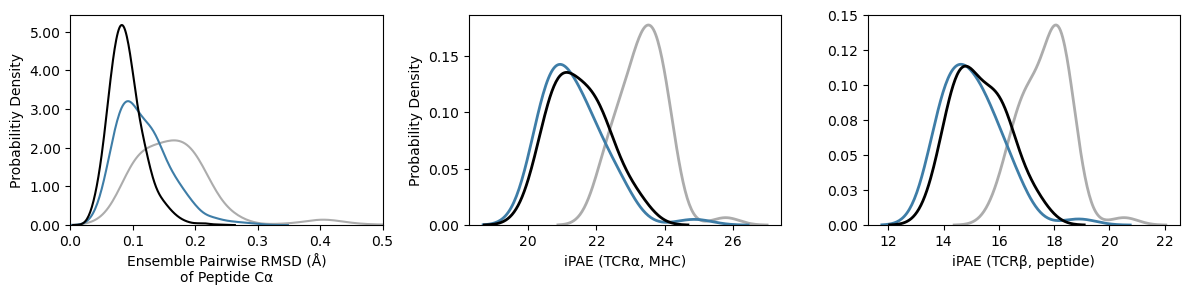

In [34]:
fig, axes = plt.subplots(figsize=(4*3,3),ncols=3)
fontsize=10




ax=axes[0]
sns.kdeplot(data=TCR1_examples_rmsd, x="Ensemble Pairwise RMSD (Å)",
                 palette=custom_colors, hue_order=custom_labels.values(),hue="Peptide",bw_adjust=1.3,legend=False,ax=ax)
ax.set_ylabel('Probabilitiy Density',fontsize=fontsize)

ax.set_xlabel('Ensemble Pairwise RMSD (Å)\nof Peptide Cα',fontsize=fontsize)
ax.set_xlim([0,.5])


ax=axes[2]
sns.kdeplot(TCR1_examples, x='avg_pae_interaction_B_P',lw=2,clip=[0,32],hue='Peptide',hue_order=custom_order,
            palette=custom_colors,ax=ax,bw_adjust=1.3,legend=False)
ax.set_ylabel('')
ax.set_xlabel(r'iPAE (TCRβ, peptide)',fontsize=fontsize) #,color='blue',fontweight='bold')
ax=axes[1]
sns.kdeplot(TCR1_examples, x='avg_pae_interaction_A_M',lw=2,clip=[0,32],hue='Peptide',hue_order=custom_order,
            palette=custom_colors,ax=ax,bw_adjust=1.3,legend=False)

ax.set_ylabel('Probability Density',fontsize=fontsize)

ax.set_xlabel(r'iPAE (TCRα, MHC)',fontsize=fontsize) #color='purple',fontweight='bold')

for ax in axes:
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))




fig.tight_layout()
fig.savefig('together.svg')

# fig.savefig('rmsd_without_legend.svg')



## Code for panel f


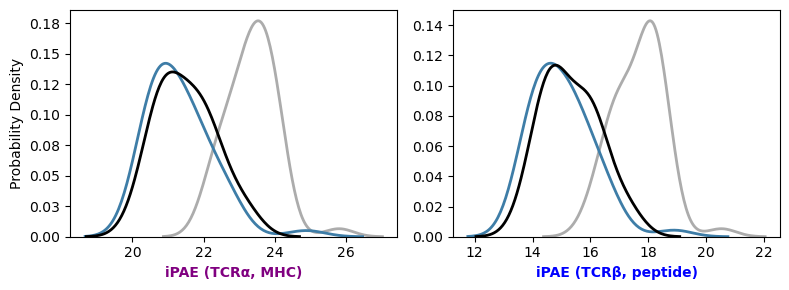